# 8.4 EDPs Parabólicas

Consideremos uma EDP geral de segunda ordem em duas variáveis independentes $x$ e $y$, que é escrita como

\begin{gather*}
A(x, y) \frac{\partial^2 u}{\partial x^2}+B(x, y) \frac{\partial^2 u}{\partial x \partial y}+C(x, y) \frac{\partial^2 u}{\partial y^2}=f\left(x, y, u, \frac{\partial u}{\partial x}, \frac{\partial u}{\partial y}\right) \\
\text{para} \ x_0 \leq x \leq x_f, y_0 \leq y \leq y_f
\end{gather*}

com as condições de contorno dadas por

$$
\begin{array}{ll}
u\left(x, y_0\right)=b_{y 0}(x), & u\left(x, y_f\right)=b_{y f}(x),  \\
u\left(x_0, y\right)=b_{x 0}(y), & \text{e} \quad u\left(x_f, y\right)=b_{x f}(y)
\end{array}
$$

As EDP elípticas são aquelas em que $B^2-4 A C=0$ e estāo associadas estados de difusão.

Um exemplo de uma EDP (equação diferencial parcial) parabólica é a equação do calor unidimensional, que descreve a distribuição de temperatura $u(x, t)$ ( $x$ é a posição, $t$ é o tempo), dada por:

\begin{equation*}
A \frac{\partial^2 u(x, t)}{\partial x^2}=\frac{\partial u(x, t)}{\partial t} \quad \text { para } 0 \leq x \leq x_f, \quad 0 \leq t \leq T 
\tag{1}
\end{equation*}


Para que essa equação possa ser resolvida, devem ser fornecidas as condições de contorno $u(0, t)= b_0(t)$ e $u\left(x_f, t\right)=b_{x f}(t)$ , bem como a condição inicial $u(x, 0)=i_0(x)$ 

A constante $A$ (ou $\alpha^2$) é a **difusividade térmica** do material, relacionada à condutividade térmica $k'$, à densidade $\rho$ e ao calor específico $C$ por

$$\alpha^2 = \frac{k'}{\rho\, C}$$

A tabela abaixo apresenta valores típicos para materiais de uso comum em engenharia:

| Material | $\alpha^2$ (cm²/s) |
|---|---|
| Cobre | 18,5 |
| Alumínio | 0,8418 |
| Ferro | 0,23 |
| Aço carbono | 0,1172 |
| Aço inox | 0,03352 |
| Madeira pinus | 0,00082 |

A difusividade do cobre é cerca de **22 000 vezes** maior que a da madeira, o que explica por que metais atingem equilíbrio térmico muito mais rapidamente que materiais isolantes.

### 1. O Método Explícito de Euler para Frente

Para aplicar o método das diferenças finitas, dividimos o domínio espacial $\left[0, x_f\right]$ em $M$ partes, cada uma com comprimento $\Delta x=x_f / M$, e dividimos o domínio temporal $[0, T]$ em $N$ intervalos cada um com duração $\Delta t=T / N$.

Em seguida, substituímos a derivada parcial de segunda ordem no lado esquerdo e a derivada parcial de primeira ordem no lado direito da equação (1) pela aproximação de diferenças centrais e pela aproximação de diferenças progressivas, respectivamente, obtendo:

\begin{equation*}
A \frac{u_{i+1}^k-2 u_i^k+u_{i-1}^k}{\Delta x^2}=\frac{u_i^{k+1}-u_i^k}{\Delta t} 
\tag{2}
\end{equation*}

Isso pode ser reescrito no seguinte algoritmo, chamado de método explícito de Euler para frente, que deve ser resolvido iterativamente:

\begin{equation*}
u_i^{k+1}=r\left(u_{i+1}^k+u_{i-1}^k\right)+(1-2 r) u_i^k \quad \text{com} \ r=A \frac{\Delta t}{\Delta x^2} \tag{3}
\end{equation*}

para $i=1,2, \ldots, M-1$.

Para encontrar a condiçāo de estabilidade desse algoritmo, substituímos uma soluçāo tentativa
\begin{equation*}
u_i^k=\lambda^k e^{j i \pi / P} \quad(P \text { é qualquer inteiro não nulo })
\tag{4}
\end{equation*}
na Eq. (3), obtendo:
\begin{equation*}
\lambda=r\left(e^{j \pi / P}+e^{-j \pi / P}\right)+(1-2 r)=1-2 r(1-\cos (\pi / P))
\tag{5}
\end{equation*}
Como devemos ter $|\lambda| \leq 1$ para evitar divergência, a condiçāo de estabilidade resulta em:
\begin{equation*}
r=A \frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}
\tag{6}
\end{equation*}
Isso implica que, à medida que diminuímos o intervalo espacial $\Delta x$ para obter maior precisāo, também precisamos diminuir o passo de tempo $\Delta t$, ao custo de mais computaçōes, para nāo perder a estabilidade.

A rotina em Python `heat_exp( )` foi desenvolvida para implementar esse algoritmo.

### Forma matricial do método explícito

O algoritmo explícito admite uma formulação matricial compacta. Definindo o vetor solução no instante $t_n$:

$$\mathbf{u}^n = \begin{bmatrix} u_0^n \\ u_1^n \\ \vdots \\ u_{M-1}^n \\ u_M^n \end{bmatrix}$$

a equação de propagação $u_i^{n+1} = r\,(u_{i+1}^n + u_{i-1}^n) + (1-2r)\,u_i^n$ torna-se uma única multiplicação de matrizes:

$$\mathbf{u}^{n+1} = \mathbf{B}\,\mathbf{u}^n, \qquad n = 0, 1, 2, \ldots$$

A **matriz de propagação** $\mathbf{B}$ é tridiagonal:

$$\mathbf{B} = \begin{bmatrix}
1 & 0 & & & 0 \\
r & 1{-}2r & r & & \\
& \ddots & \ddots & \ddots & \\
& & r & 1{-}2r & r \\
0 & & & 0 & 1
\end{bmatrix}$$

As linhas da fronteira preservam os valores das condições de Dirichlet. Esta perspectiva revela que o critério de estabilidade $r \leq 1/2$ é equivalente a exigir que todos os autovalores de $\mathbf{B}$ tenham módulo $\leq 1$.

**Exemplo:** Equação de difusão com solução exata

$$\frac{\partial u}{\partial t} = D\,\frac{\partial^2 u}{\partial x^2}, \quad u(0,t)=u(L,t)=0, \quad u(x,0)=\sin(\pi x/L)$$

Solução exata: $u(x,t) = e^{-\pi^2 D t/L^2}\sin(\pi x/L)$

Vamos construir $\mathbf{B}$ explicitamente e comparar a propagação numérica com a solução de referência.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
D = 0.1
hx = 0.05
ht = 0.0125
r = D * ht / hx**2
print(f"r = {r:.4f}  (criterio de estabilidade: r <= 0.5)")

x = np.linspace(0, L, int(L/hx) + 1)
u0 = np.sin(np.pi * x / L)

# Monta a matriz de propagação B
N = len(x)
B = np.eye(N)
for i in range(1, N - 1):
    B[i, i-1] = r
    B[i, i]   = 1 - 2*r
    B[i, i+1] = r

# Propaga e armazena
n_steps = 480
sol = np.zeros((n_steps + 1, N))
sol[0] = u0
for n in range(n_steps):
    sol[n+1] = B @ sol[n]

# Solução exata
sol_ex = lambda x, t: np.exp(-np.pi**2 * D * t / L**2) * np.sin(np.pi * x / L)

fig, ax = plt.subplots(figsize=(6, 3))
for n in [200, 350, 480]:
    t_n = n * ht
    ax.plot(x, sol[n], label=f't = {t_n:.2f} s')
    ax.plot(x, sol_ex(x, t_n), 'k--', lw=0.8)
ax.plot([], [], 'k--', label='Solucao exata')
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.set_title('Propagacao matricial vs. solucao exata (tracejado)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Experimento de instabilidade:** aumente `ht` para `0.013` ($r \approx 0{,}52 > 1/2$) e execute novamente para observar a divergência da solução.

In [1]:
import numpy as np

def heat_exp(a, xf, T, it0, bx0, bxf, M, N):
    """
    Resolve a * u_xx = u_t para 0 <= x <= xf, 0 <= t <= T

    it0(x): condição inicial
    bx0(t): condição de contorno em x = 0
    bxf(t): condição de contorno em x = xf
    """

    dx = xf / M
    x = np.linspace(0, xf, M + 1)

    dt = T / N
    t = np.linspace(0, T, N + 1)

    # matriz solução (linhas: espaço, colunas: tempo)
    u = np.zeros((M + 1, N + 1))

    # condição inicial
    for i in range(M + 1):
        u[i, 0] = it0(x[i])

    # condições de contorno
    for n in range(N + 1):
        u[0, n] = bx0(t[n])
        u[M, n] = bxf(t[n])

    r = a * dt / dx**2
    r1 = 1 - 2 * r

    # esquema explícito de Euler
    for k in range(N):
        for i in range(1, M):
            u[i, k + 1] = r * (u[i + 1, k] + u[i - 1, k]) + r1 * u[i, k]

    return u, x, t

### 2. Método de Euler Implícito Regressivo

Nesta seçāo, consideramos outro algoritmo chamado método implícito de Euler para trás, que surge ao substituir a aproximaçāo por diferenças regressivas (backward difference) para a derivada parcial de primeira ordem no lado direito da Eq. (1), resultando em:

\begin{equation*}
A \frac{u_{i+1}^k-2 u_i^k+u_{i-1}^k}{\Delta x^2}=\frac{u_i^k-u_i^{k-1}}{\Delta t}
\tag{7}
\end{equation*}

ou, equivalentemente,

\begin{equation*}
-r u_{i-1}^k+(1+2 r) u_i^k-r u_{i+1}^k=u_i^{k-1} \quad \operatorname{com} r=A \frac{\Delta t}{\Delta x^2}
\tag{8}
\end{equation*}

para $i=1,2, \ldots, M-1$.

Se os valores de $u_0^k$ e $u_M^k$ nas extremidades sāo dados por condiçōes de contorno do tipo Dirichlet, entāo a equaçāo acima pode ser escrita como um sistema de equações lineares simultâneas:

\begin{equation*}
\left[\begin{array}{cccccc}
1+2 r & -r & 0 & \cdots & 0 & 0 \\
-r & 1+2 r & -r & \cdots & 0 & 0 \\
0 & -r & 1+2 r & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & 1+2 r & -r \\
0 & 0 & 0 & \cdots & -r & 1+2 r
\end{array}\right]\left[\begin{array}{c}
u_1^k \\
u_2^k \\
u_3^k \\
\vdots \\
u_{M-2}^k \\
u_{M-1}^k
\end{array}\right]=\left[\begin{array}{c}
u_1^{k-1}+r u_0^k \\
u_2^{k-1} \\
u_3^{k-1} \\
\vdots \\
u_{M-2}^{k-1} \\
u_{M-1}^{k-1}+r u_M^k
\end{array}\right]
\tag{9}
\end{equation*}

A matriz dos coeficientes é tridiagonal e, portanto, o sistema linear pode ser resolvido eficientemente por métodos especializados para matrizes tridiagonais, como o algoritmo de Thomas.

E quanto ao caso em que são fornecidos os valores de $\left.\frac{\partial u}{\partial x}\right|_{x=0}=b_0^{\prime}(t)$ em uma das extremidades?

Nesse caso, aproximamos essa condiçāo de contorno do tipo Neumann por

\begin{equation*}
\frac{u_1^k-u_{-1}^k}{2 \Delta x}=b_0^{\prime}(k), 
\tag{10}
\end{equation*}

e a combinamos com uma equaçāo adicional associada à variável desconhecida $u_0^k$,

\begin{equation*}
-r u_{-1}^k+(1+2 r) u_0^k-r u_1^k=u_0^{k-1}, 
\tag{11}
\end{equation*}

para obter

\begin{equation*}
(1+2 r) u_0^k-2 r u_1^k=u_0^{k-1}-2 r b_0^{\prime}(k) \Delta x . 
\tag{12}
\end{equation*}


Acrescentamos essa equaçāo ao sistema dado pela Eq. (9), obtendo

$$
\left[\begin{array}{ccccccc}
1+2 r & -2 r & 0 & 0 & \cdots & 0 & 0 \\
-r & 1+2 r & -r & 0 & \cdots & 0 & 0 \\
0 & -r & 1+2 r & -r & \cdots & 0 & 0 \\
0 & 0 & -r & 1+2 r & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & \cdots & 1+2 r & -r \\
0 & 0 & 0 & \cdots & \cdots & -r & 1+2 r
\end{array}\right]\left[\begin{array}{c}
u_0^k \\
u_1^k \\
u_2^k \\
u_3^k \\
\vdots \\
u_{M-2}^k \\
u_{M-1}^k
\end{array}\right]=\left[\begin{array}{c}
u_0^{k-1}-2 r b_0^{\prime}(k) \Delta x \\
u_1^{k-1} \\
u_2^{k-1} \\
u_3^{k-1} \\
\vdots \\
u_{M-2}^{k-1} \\
u_{M-1}^{k-1}+r u_M^k
\end{array}\right] .
$$

Observe que a condiçāo de Neumann é incorporada eliminando-se o ponto fictício $u_{-1}^k$. Como consequência, a primeira linha da matriz tridiagonal é modificada: o coeficiente $-r$ que apareceria em frente a $u_1^k$ torna-se $-2 r$, enquanto o termo independente passa a conter a contribuiçāo da derivada prescrita na fronteira, $-2 r b_0^{\prime}(k) \Delta x$. Dessa forma, a condiçāo de fluxo (ou gradiente) na extremidade é incorporada diretamente ao sistema linear implícito.

Equaçōes como a Eq. (9) ou a Eq. (13) sāo particularmente interessantes porque podem ser resolvidas de forma muito eficiente, explorando sua estrutura tridiagonal, e têm estabilidade garantida devido à sua dominância diagonal. A estabilidade incondicional da Eq. (9) pode ser demonstrada substituindo a Eq. (4) na Eq. (8):

$$
-r e^{-j \pi / P}+(1+2 r)-r e^{j \pi / P}=\frac{1}{\lambda},
$$

ou, equivalentemente,

\begin{equation*}
\lambda=\frac{1}{1+2 r(1-\cos (\pi / P))}, \quad|\lambda| \leq 1 . \tag{9.2.14}
\end{equation*}


Como $r \geq 0$ e $1-\cos (\pi / P) \geq 0$, o denominador é sempre maior ou igual a 1 . Consequentemente,

$$
0<\lambda \leq 1,
$$

o que implica que $|\lambda| \leq 1$ para qualquer escolha de $\Delta t$ e $\Delta x$. Portanto, o método é incondicionalmente estável, isto é, nāo exige nenhuma restriçāo entre o passo temporal e o espaçamento da malha para manter a estabilidade numérica.

A rotina a seguir, denominada `heat_imp( )`, implementa esse algoritmo para resolver a EDP (1) com condiçōes de contorno usuais (do tipo Dirichlet), utilizando o sistema linear dado pela Eq. (9).

In [2]:
import numpy as np

def heat_imp(a, xf, T, it0, bx0, bxf, M, N):
    """
    Resolve a*u_xx = u_t para 0 <= x <= xf e 0 <= t <= T
    usando o método implícito de Euler.

    Parâmetros
    ----------
    a   : coeficiente de difusão
    xf  : comprimento do domínio espacial
    T   : tempo final
    it0 : função da condição inicial u(x,0)
    bx0 : função da condição de contorno em x=0
    bxf : função da condição de contorno em x=xf
    M   : número de subintervalos espaciais
    N   : número de subintervalos temporais

    Retorna
    -------
    u : matriz (M+1) x (N+1)
    x : vetor espacial
    t : vetor temporal
    """

    dx = xf / M
    x = np.linspace(0, xf, M + 1)

    dt = T / N
    t = np.linspace(0, T, N + 1)

    # solução
    u = np.zeros((M + 1, N + 1))

    # condição inicial
    for i in range(M + 1):
        u[i, 0] = it0(x[i])

    # condições de contorno
    for n in range(N + 1):
        u[0, n] = bx0(t[n])
        u[M, n] = bxf(t[n])

    r = a * dt / dx**2
    r2 = 1 + 2 * r

    # matriz tridiagonal A
    A = np.zeros((M - 1, M - 1))

    for i in range(M - 1):
        A[i, i] = r2

        if i > 0:
            A[i - 1, i] = -r
            A[i, i - 1] = -r

    # avanço temporal
    for k in range(1, N + 1):

        b = u[1:M, k - 1].copy()

        # contribuição das fronteiras
        b[0] += r * u[0, k]
        b[-1] += r * u[M, k]

        u[1:M, k] = np.linalg.solve(A, b)

    return u, x, t

### 3. O Método de Crank-Nicholson

Voltemos agora à Eq. (7) e tentemos aprimorar o método implícito de Euler regressivo. A aproximaçāo por diferenças no lado esquerdo é tomada no instante de tempo $k$, enquanto a aproximaçāo por diferenças no lado direito é tomada no ponto médio entre os instantes $k$ e $k-1$, se a interpretarmos como uma aproximaçāo por diferença central com passo temporal $\Delta t / 2$. Isso nāo parece inconsistente?

Que tal tomar as aproximaçōes por diferenças de ambos os lados no mesmo instante de tempo — por exemplo, no ponto médio entre $k+1$ e $k$ - para manter um equilíbrio? Para isso, tomamos a média das aproximaçōes por diferenças centrais do lado esquerdo nos instantes $k+1$ e $k$, obtendo

\begin{equation*}
\frac{A}{2}\left(\frac{u_{i+1}^{k+1}-2 u_i^{k+1}+u_{i-1}^{k+1}}{\Delta x^2}+\frac{u_{i+1}^k-2 u_i^k+u_{i-1}^k}{\Delta x^2}\right)=\frac{u_i^{k+1}-u_i^k}{\Delta t} . \tag{15}
\end{equation*}


Essa expressāo conduz ao chamado método de Crank-Nicholson:

\begin{equation*}
-r u_{i+1}^{k+1}+2(1+r) u_i^{k+1}-r u_{i-1}^{k+1}=r u_{i+1}^k+2(1-r) u_i^k+r u_{i-1}^k, 
\tag{16}
\end{equation*}

com

$$
r=A \frac{\Delta t}{\Delta x^2} .
$$


O método de Crank-Nicholson pode ser visto como uma combinaçāo dos métodos explícito e implícito, utilizando a média entre os operadores espaciais avaliados nos tempos $k$ e $k+1$. Como resultado, ele mantém a estabilidade incondicional do método implícito e alcança segunda ordem de precisão no tempo, enquanto os métodos de Euler direto e regressivo possuem apenas primeira ordem de precisão temporal. Por essa razāo, o método de Crank-Nicholson é amplamente utilizado na resoluçāo numérica da equaçāo do calor e de outras equaçōes parabólicas.

Com condições de contorno de Dirichlet/Neumann em $x_0$ e $x_M$, respectivamente A Eq. (16) pode ser escrita no seguinte sistema tridiagonal de equaçōes:

\begin{align*}
& {\left[\begin{array}{cccccc}
2(1+r) & -r & 0 & \cdot & 0 & 0 \\
-r & 2(1+r) & -r & \cdot & 0 & 0 \\
0 & -r & 2(1+r) & \cdot & 0 & 0 \\
\cdot & \cdot & \cdot & \cdot & \cdot & \cdot \\
0 & 0 & 0 & \cdot & 2(1+r) & -r \\
0 & 0 & 0 & \cdot & -2 r & 2(1+r)
\end{array}\right]\left[\begin{array}{c}
u_1^{k+1} \\
u_2^{k+1} \\
u_3^{k+1} \\
\cdot \\
u_{M-1}^{k+1} \\
u_M^{k+1}
\end{array}\right]} \\
& =\left[\begin{array}{cccccc}
2(1-r) & r & 0 & \cdot & 0 & 0 \\
r & 2(1-r) & r & \cdot & 0 & 0 \\
0 & r & 2(1-r) & \cdot & 0 & 0 \\
\cdot & \cdot & \cdot & \cdot & \cdot & \cdot \\
0 & 0 & 0 & \cdot & 2(1-r) & r \\
0 & 0 & 0 & \cdot & 2 r & 2(1-r)
\end{array}\right]\left[\begin{array}{c}
u_1^k \\
u_2^k \\
u_3^k \\
\cdot \\
u_{M-1}^k \\
u_M^k
\end{array}\right]+\left[\begin{array}{c}
r\left(u_0^{k+1}+u_0^k\right) \\
0 \\
0 \\
\cdot \\
0 \\
2 r\left(b_M^{\prime}(k+1)+b_M^{\prime}(k)\right)
\end{array}\right] \tag{9.2.17}
\end{align*}

Esse sistema também pode ser resolvido de maneira muito eficiente devido à sua estrutura tridiagonal. Além disso, sua estabilidade incondicional pode ser demonstrada substituindo a Eq. (4) na Eq. (16), obtendo-se

$$
2 \lambda(1+r(1-\cos (\pi / P)))=2(1-r(1-\cos (\pi / P))),
$$

ou seja,

\begin{equation*}
\lambda=\frac{1-r(1-\cos (\pi / P))}{1+r(1-\cos (\pi / P))}, \quad|\lambda| \leq 1 .
\tag{18}
\end{equation*}

O algoritmo `heat_CN()` implementa o método de Crank-Nicholson.

In [3]:
def heat_CN(a, xf, T, it0, bx0, bxf, M, N):
    """
    Método de Crank-Nicolson para a equação do calor

        u_t = a u_xx

    em 0 <= x <= xf, 0 <= t <= T.
    """

    dx = xf / M
    x = np.linspace(0.0, xf, M + 1)

    dt = T / N
    t = np.linspace(0.0, T, N + 1)

    u = np.zeros((M + 1, N + 1))

    # condição inicial
    for i in range(M + 1):
        u[i, 0] = it0(x[i])

    # condições de contorno
    for n in range(N + 1):
        u[0, n] = bx0(t[n])
        u[M, n] = bxf(t[n])

    r = a * dt / dx**2

    r1 = 2 * (1 + r)
    r2 = 2 * (1 - r)

    # matriz tridiagonal
    A = np.zeros((M - 1, M - 1))

    for i in range(M - 1):
        A[i, i] = r1

        if i > 0:
            A[i - 1, i] = -r
            A[i, i - 1] = -r

    # avanço temporal
    for k in range(1, N + 1):

        b = (
            np.concatenate((
                [r * u[0, k]],
                np.zeros(M - 3),
                [r * u[M, k]]
            ))
            + r * (u[0:M-1, k-1] + u[2:M+1, k-1])
            + r2 * u[1:M, k-1]
        )

        u[1:M, k] = np.linalg.solve(A, b)

    return u, x, t

**Exemplo 1:** EDP Parabólica Unidimensional: Equação do Fluxo de Calor

Considere a EDP parabólica

\begin{equation*}
\frac{\partial^2 u(x, t)}{\partial x^2}=\frac{\partial u(x, t)}{\partial t}, \quad 0 \leq x \leq 1, \quad 0 \leq t \leq 0.1 . \tag{E.1}
\end{equation*}

com a condiçāo inicial e as condiçōes de contorno

\begin{equation*}
u(x, 0)=\sin (\pi x), \quad u(0, t)=0, \quad u(1, t)=0 . \tag{E9.2.2}
\end{equation*}


Construímos o programa `solve_heat` para utilizar as rotinas `heat_exp()` , `heat_imp()` e `heat_CN()` na resoluçāo dessa equaçāo. 

Observe que, com o espaçamento espacial

$$
\Delta x=\frac{x_f}{M}=\frac{1}{20}
$$

e o passo temporal

$$
\Delta t=\frac{T}{N}=\frac{0.1}{100}=0.001
$$

temos

\begin{equation*}
r=A \frac{\Delta t}{\Delta x^2}=1 \cdot \frac{0.001}{(1 / 20)^2}=0.4 . \tag{E9.2.3}
\end{equation*}

Como esse valor satisfaz a condiçāo de estabilidade

$$
r \leq \frac{1}{2},
$$

dada pela Eq. (6), os três métodos produzem resultados satisfatórios, apresentando um erro relativo de aproximadamente 0.013 .

Entretanto, se diminuirmos o espaçamento espacial para

$$
\Delta x=\frac{1}{25},
$$

a fim de obter uma resoluçāo espacial mais refinada, obtemos

$$
r=0.625,
$$

o que viola a condiçāo de estabilidade do método explícito. Nessa situaçāo, o método de Euler direto ( `heat_exp( )` ) torna-se instável e a soluçāo diverge. Em contraste, o método implícito de Euler regressivo ( `heat_imp( )` ) e o método de Crank-Nicholson ( `heat_CN( )` ) continuam funcionando adequadamente, conforme pode ser vistos nos gráficos.

Por outro lado, se mantivermos o espaçamento espacial em

$$
\Delta x=\frac{1}{25}
$$
e reduzirmos o passo temporal para

$$
\Delta t=\frac{0.1}{120},
$$

temos

$$
r=\frac{0.1 / 120}{(1 / 25)^2} \approx 0.521 .
$$


Esse valor ainda está muito próximo do limite de estabilidade do método explícito. Ao utilizar um passo temporal suficientemente pequeno (de forma que a condiçāo $r \leq 1 / 2$ seja efetivamente satisfeita), o método explícito volta a apresentar comportamento estável. Nessas condiçōes, tanto o método explícito quanto os métodos implícitos produzem soluçōes bastante precisas, com erro relativo inferior a 0.001.

Isso significa que, com cerca de 30\% a mais de esforço computacional, obtém-se uma soluçāo mais precisa, apesar de o valor

$$
r=0.5208
$$

nāo satisfazer rigorosamente a condiçāo de estabilidade.
Esse resultado sugere que a condiçāo

$$
r \leq \frac{1}{2}
$$

para a estabilidade do método explícito de Euler direto nāo é uma condiçāo necessária, mas apenas uma condiçāo suficiente.

Além disso, quando o método explícito converge, sua precisāo pode ser superior à do método implícito de Euler regressivo. Entretanto, de modo geral, ela nāo supera a precisāo obtida pelo método de CrankNicholson.

In [5]:
import matplotlib.pyplot as plt

Erro método explícito      = 1.762968e-02
Erro método implícito      = 1.053045e-03
Erro Crank-Nicolson        = 1.050821e-03


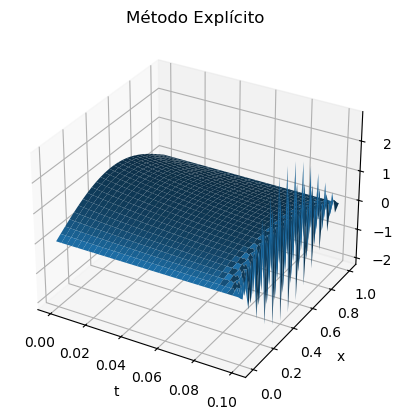

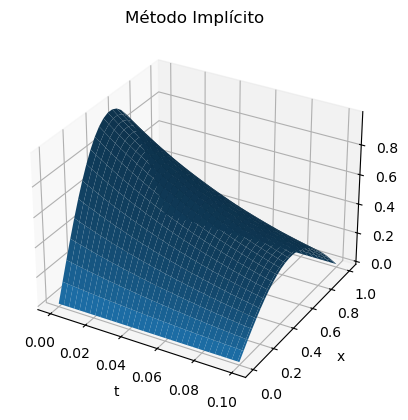

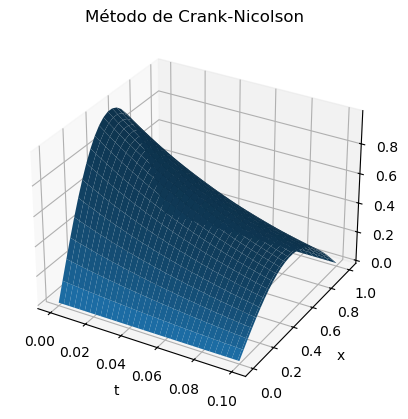

In [6]:
#solve_heat

# parâmetro da equação u_t = a*u_xx
a = 1.0

# condição inicial
it0 = lambda x: np.sin(np.pi * x)

# condições de contorno
bx0 = lambda t: 0.0
bxf = lambda t: 0.0

# parâmetros da malha
xf = 1.0
M = 25

T = 0.1
N = 100

# solução analítica
uo = lambda x, t: np.sin(np.pi * x) * np.exp(-np.pi**2 * t)

# Método explícito
u1, x, t = heat_exp(a, xf, T, it0, bx0, bxf, M, N)

fig = plt.figure(1)
ax = fig.add_subplot(111, projection='3d')
Tgrid, Xgrid = np.meshgrid(t, x)
ax.plot_surface(Tgrid, Xgrid, u1)
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_title('Método Explícito')

# Método implícito
u2, x, t = heat_imp(a, xf, T, it0, bx0, bxf, M, N)

fig = plt.figure(2)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Tgrid, Xgrid, u2)
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_title('Método Implícito')

# Método de Crank-Nicolson
u3, x, t = heat_CN(a, xf, T, it0, bx0, bxf, M, N)

fig = plt.figure(3)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Tgrid, Xgrid, u3)
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_title('Método de Crank-Nicolson')

# solução analítica na malha
X, Tm = np.meshgrid(x, t, indexing='ij')
Uo = uo(X, Tm)

# evitar divisão por zero
aUo = np.abs(Uo) + np.finfo(float).eps

MN = M * N

# erros relativos normalizados
err1 = np.linalg.norm((u1 - Uo) / aUo) / MN
err2 = np.linalg.norm((u2 - Uo) / aUo) / MN
err3 = np.linalg.norm((u3 - Uo) / aUo) / MN

print(f"Erro método explícito      = {err1:e}")
print(f"Erro método implícito      = {err2:e}")
print(f"Erro Crank-Nicolson        = {err3:e}")

plt.show()

**Comentário:**

Este exemplo evidencia a principal diferença entre os três métodos:
- **Euler explícito (Forward Euler):**
  - Simples de implementar;
  - Exige a condição de estabilidade: $r=A \frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}$

  - Pode divergir quando a malha espacial é refinada sem uma reduçāo correspondente do passo temporal.
  
- **Euler implícito (Backward Euler):**
  - Incondicionalmente estável;
  - Requer a soluçāo de um sistema linear a cada passo de tempo;
  - Possui precisāo temporal de primeira ordem.
    
- **Crank-Nicholson:** 
  - Também é incondicionalmente estável;
  - Requer a soluçāo de um sistema linear tridiagonal;
  - Possui precisāo temporal de segunda ordem;
  - Geralmente oferece a melhor combinaçāo entre estabilidade e precisāo.

Para este problema específico, a soluçāo analítica é

$$
u(x, t)=\sin (\pi x) e^{-\pi^2 t}
$$

que é a expressāo utilizada para calcular os erros relativos das aproximaçōes numéricas.

### Equação do calor 2D (transiente)

A extensão da equação do calor para domínios bidimensionais é

$$\frac{\partial u}{\partial t} = \alpha \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right), \quad (x,y) \in \Omega, \quad t > 0$$

Usando diferenças finitas centrais no espaço e progressivas no tempo, com $\Delta x = \Delta y = h$, a equação de diferenças é

$$u_{i,j}^{k+1} = \gamma\left(u_{i+1,j}^k + u_{i-1,j}^k + u_{i,j+1}^k + u_{i,j-1}^k - 4\,u_{i,j}^k\right) + u_{i,j}^k, \qquad \gamma = \alpha\frac{\Delta t}{h^2}$$

A condição de estabilidade para o caso 2D é mais restritiva que no caso 1D: $\gamma \leq 1/4$.

**Exemplo 2:** Placa retangular com aquecimento nas bordas

Placa de $50 \times 30$ unidades, temperatura inicial nula em toda a região interior. Condições de contorno constantes: borda superior a $80\,°C$, borda direita a $50\,°C$, bordas esquerda e inferior a $0\,°C$.

Parâmetros: $\alpha = 2$, $h = 0{,}5$, $\Delta t = 0{,}01$ s $\Rightarrow$ $\gamma = 0{,}08 < 0{,}25$ (estável).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

xmax, ymax = 50, 30
kmax = 500
alpha = 2.0
h     = 0.5
ht    = 0.01
gamma = alpha * ht / h**2

print(f"gamma = {gamma:.4f}  (criterio 2D: gamma <= 0.25)")

u = np.zeros((kmax, ymax, xmax))
u[:, -1, :] = 80.0
u[:, :, -1] = 50.0

for k in range(kmax - 1):
    u[k+1, 1:-1, 1:-1] = (
        gamma * (
            u[k, 2:,   1:-1] + u[k, :-2,  1:-1]
          + u[k, 1:-1, 2:]   + u[k, 1:-1, :-2]
          - 4 * u[k, 1:-1, 1:-1]
        )
        + u[k, 1:-1, 1:-1]
    )
    u[k+1, -1, :] = 80.0
    u[k+1, :, -1] = 50.0

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, k in zip(axes, [0, kmax//2, kmax-1]):
    im = ax.imshow(u[k], cmap='jet', vmin=0, vmax=80, origin='lower',
                   extent=[0, xmax*h, 0, ymax*h])
    ax.set_title(f't = {k*ht:.2f} s')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Distribuicao de temperatura — equacao do calor 2D')
plt.tight_layout()
plt.show()

In [ ]:
# Animação da evolução temporal
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(u[0], cmap='jet', vmin=0, vmax=80, origin='lower',
               extent=[0, xmax*h, 0, ymax*h])
plt.colorbar(im, ax=ax, label='Temperatura (graus C)')
ax.set_xlabel('x')
ax.set_ylabel('y')

def _animate(k):
    im.set_array(u[k])
    ax.set_title(f't = {k*ht:.3f} s')
    return [im]

anim = animation.FuncAnimation(fig, _animate, frames=kmax,
                                interval=30, blit=True, repeat=False)
from IPython.display import HTML
HTML(anim.to_jshtml())

### Problemas: EDPs Parabólicas - Equações do Calor

Modifique o programa `solve_heat` para que ele possa resolver as seguintes EDPs utilizando o método explícito de Euler direto, o método implícito de Euler regressivo e o método de Crank-Nicholson.

**(a)** $$
\frac{\partial^2 u(x, t)}{\partial x^2}=\frac{\partial u(x, t)}{\partial t}, \quad 0 \leq x \leq 1, \quad 0 \leq t \leq 0.1
$$

com as condiçōes inicial e de contorno

\begin{equation*}
u(x, 0)=x^4, \quad u(0, t)=0, \quad u(1, t)=1 . \tag{P9.4.2}
\end{equation*}

**(i)** Com a região de solução dividida em

$$
M \times N=10 \times 20,
$$

o método explícito de Euler direto converge?
Qual é o valor de

$$
r=A \frac{\Delta t}{(\Delta x)^2} ?
$$

**(ii)** Se aumentarmos $M$ e $N$ para

$$
M \times N=20 \times 40,
$$

visando obter maior precisāo, o método explícito de Euler direto ainda converge?
Qual é o valor de

$$
r=A \frac{\Delta t}{(\Delta x)^2} ?
$$

**(iii)** Qual deve ser o número $N$ de subintervalos ao longo do eixo $t$ para que o valor de $r$ permaneça o mesmo quando $M=20$ ?

Com esse valor de $r$, o método explícito de Euler direto converge?

**(b)** Resolva o problema de condução de calor

$$u_{xx} = 4\,u_t, \quad 0 < x < 2, \quad t > 0$$

$$u(0,t) = 0, \quad u(2,t) = 0, \quad u(x,0) = 2\operatorname{sen}\!\left(\frac{\pi x}{2}\right) - \operatorname{sen}(\pi x) + 4\operatorname{sen}(2\pi x)$$

Compare com a solução exata $u(x,t) = 2\,e^{-\pi^2 t/16}\operatorname{sen}(\pi x/2) - e^{-\pi^2 t/4}\operatorname{sen}(\pi x) + 4\,e^{-\pi^2 t}\operatorname{sen}(2\pi x)$.

**Problemas adicionais — Barra de 40 cm** (Fonte: Boyce e DiPrima, 2024)

Extremidades mantidas a $0\,°C$, $\alpha^2 = 1$. Para cada condição inicial abaixo, resolva numericamente com os três métodos e construa o gráfico de $u(x,t)$ para alguns instantes de tempo.

**(c)** $u(x,0) = 50, \quad 0 < x < 40$

**(d)** $u(x,0) = \begin{cases} x, & 0 \leq x < 20 \\ 40-x, & 20 \leq x \leq 40 \end{cases}$

**(e)** $u(x,0) = \begin{cases} 0, & 0 \leq x < 10 \\ 50, & 10 \leq x \leq 30 \\ 0, & 30 < x \leq 40 \end{cases}$

**(f)** $u(x,0) = x, \quad 0 \leq x < 40$

**Análise de convergência**

**(g)** Considere a barra do Problema **(c)**. Para $t = 5$ e $x = 20$, determine quantos termos da série de Fourier são necessários para que a inclusão de mais um termo não altere as três primeiras casas decimais de $u(20,5)$. Repita para $t = 20$ e $t = 80$. O que se conclui sobre a velocidade de convergência?

**(h)** Repita o Problema **(g)** para a barra do Problema **(d)**.

**(i)** Repita o Problema **(g)** para a barra do Problema **(e)**.

**(j)** Repita o Problema **(g)** para a barra do Problema **(f)**.